# Did stratified re-clustering work?

**What we did.** Starting from 100,000 policies previously classified with the v1 prompt, we:

1. Filtered to `sufficiency + ambiguous` (33,603 survivors — 33.6% of the sample).
2. Fetched their Qwen3-4B embeddings from HuggingFace.
3. Ran Leiden per `(sector, sub_code)` cell, with size-adaptive resolution:
    - <30 members → single cluster
    - <300 → coarse Leiden (resolution 0.4)
    - ≥300 → default Leiden (resolution 1.0)
4. Judged 253 randomly-sampled clusters via the DeepSeek V4 intrusion task (few-shot calibrated).

**Baseline to beat.** The existing clustering (`clusters_2026-03-18`, unfiltered) scored **73.5%** judge accuracy on 433 clusters — with a 2×2 breakdown showing only **15% KEEP** vs **58% coherent-but-off-topic**.

**Target.** If stratified re-clustering works, judge accuracy on new clusters should rise (finer, purer groups) AND the coherent-but-off-topic quadrant should collapse (filter removed the non-sufficiency content).

This notebook explores that.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

ROOT = Path("../../runs/api_100k_recluster")

# Concatenate the per-sector reclustered parquets
sectors = ["BUILDING", "ENERGY", "FOOD", "INDUSTRY", "LOGISTICS",
           "MACROECONOMIC", "MATERIALS", "MOBILITY", "NATURE", "SOCIAL", "URBAN"]
frames = []
for s in sectors:
    p = ROOT / f"reclustered/{s}_reclustered_2026-06-13.parquet"
    frames.append(pd.read_parquet(p))
df = pd.concat(frames, ignore_index=True)
print(f"loaded {len(df):,} rows, {df['new_cluster_uid'].nunique():,} new clusters")

# Load the intermediate filtered.parquet — has both orig_cluster_uid and category
# for the cross-reference below
filtered = pd.read_parquet(ROOT / "filtered.parquet")
print(f"filtered.parquet: {len(filtered):,} rows")

# CO2 log
emissions = pd.read_csv(ROOT / "emissions.csv")
print(f"emissions rows: {len(emissions):,}")

loaded 33,603 rows, 915 new clusters


filtered.parquet: 33,603 rows
emissions rows: 7


## 1. Global picture — 915 clusters, ordered by sector

SOCIAL and URBAN dominate the surviving pool (they were the sufficiency-dense sectors in the 100k report). Sector rows here are ~1/3 what the classifier saw — the filter kept the strong signal and dropped the rest.

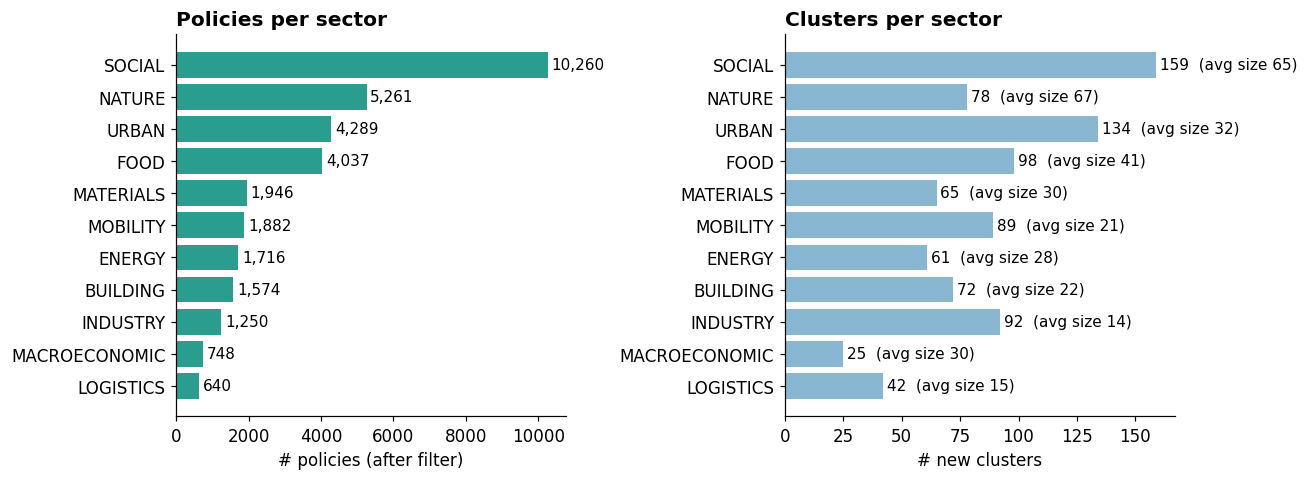

In [2]:
per_sector = df.groupby("sector").agg(
    n_policies=("policy_text", "size"),
    n_clusters=("new_cluster_uid", "nunique"),
).sort_values("n_policies", ascending=False)
per_sector["mean_size"] = per_sector["n_policies"] / per_sector["n_clusters"]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
colors = ["#2a9d8f"] * len(per_sector)

ax[0].barh(per_sector.index, per_sector["n_policies"], color=colors)
ax[0].invert_yaxis()
ax[0].set_xlabel("# policies (after filter)")
ax[0].set_title("Policies per sector", loc="left", fontweight="bold")
for i, (s, r) in enumerate(per_sector.iterrows()):
    ax[0].text(r["n_policies"] + per_sector["n_policies"].max() * 0.01, i,
               f"{int(r['n_policies']):,}", va="center", fontsize=10)

ax[1].barh(per_sector.index, per_sector["n_clusters"], color="#89b7d1")
ax[1].invert_yaxis()
ax[1].set_xlabel("# new clusters")
ax[1].set_title("Clusters per sector", loc="left", fontweight="bold")
for i, (s, r) in enumerate(per_sector.iterrows()):
    ax[1].text(r["n_clusters"] + per_sector["n_clusters"].max() * 0.01, i,
               f"{int(r['n_clusters'])}  (avg size {r['mean_size']:.0f})",
               va="center", fontsize=10)
plt.tight_layout()
plt.show()

## 2. Cluster size distribution — how balanced are the new groups?

A healthy clustering avoids two failure modes: (a) giant clusters that swallow everything (means the resolution is too coarse), and (b) mostly-singletons (means resolution is too fine). Median cluster size and the long-tail shape tell us where we sit.

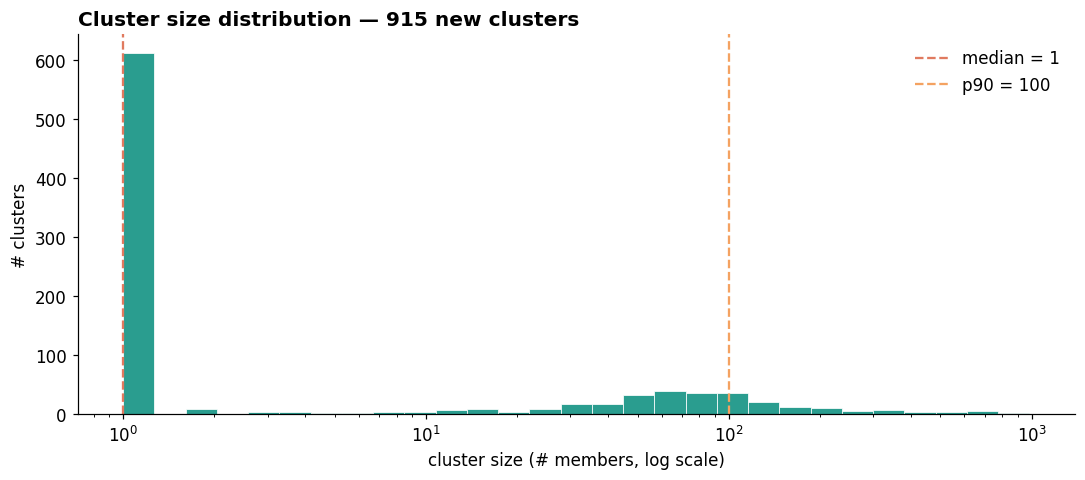

Cluster size summary:
count    915.0
mean      36.7
std       96.6
min        1.0
25%        1.0
50%        1.0
75%       39.0
max      982.0


In [3]:
sizes = df.groupby(["sector", "new_cluster_uid"]).size().rename("n_members").reset_index()

fig, ax = plt.subplots(figsize=(10, 4.5))
bins = np.logspace(0, np.log10(sizes["n_members"].max() + 1), 30)
ax.hist(sizes["n_members"], bins=bins, color="#2a9d8f", edgecolor="white", linewidth=0.5)
ax.set_xscale("log")
ax.set_xlabel("cluster size (# members, log scale)")
ax.set_ylabel("# clusters")
ax.set_title("Cluster size distribution — 915 new clusters", loc="left", fontweight="bold")
median = int(sizes["n_members"].median())
p90 = int(sizes["n_members"].quantile(0.9))
ax.axvline(median, color="#e07a5f", linestyle="--", label=f"median = {median}")
ax.axvline(p90, color="#f4a261", linestyle="--", label=f"p90 = {p90}")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print("Cluster size summary:")
print(sizes["n_members"].describe().round(1).to_string())

## 3. Sub-code composition — is each cluster mechanism-uniform?

By construction: we clustered within each `(sector, sub_code)` cell, so every cluster should have 100% of one sub-code. Ambiguous cells (no sub_code) form their own cluster group (labeled `-1`).

This chart is a sanity check that the stratification actually held.

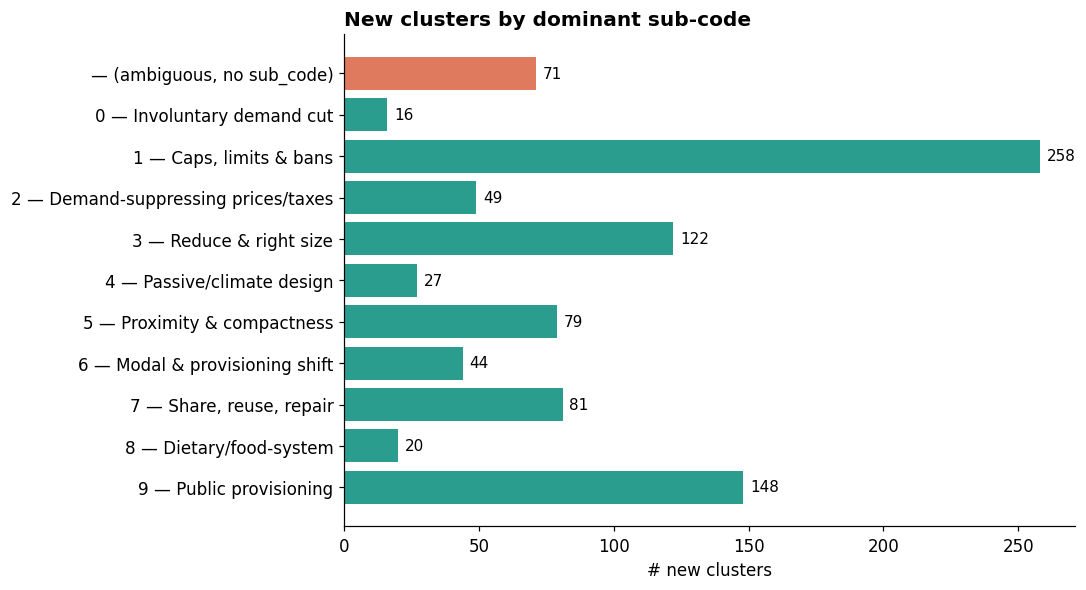

Mean sub-code purity across all 915 clusters: 100.0%
  (should be 100% since stratification is enforced by construction)


In [4]:
SUB_LABELS = {
    -1: "— (ambiguous, no sub_code)",
    0: "0 — Involuntary demand cut",
    1: "1 — Caps, limits & bans",
    2: "2 — Demand-suppressing prices/taxes",
    3: "3 — Reduce & right size",
    4: "4 — Passive/climate design",
    5: "5 — Proximity & compactness",
    6: "6 — Modal & provisioning shift",
    7: "7 — Share, reuse, repair",
    8: "8 — Dietary/food-system",
    9: "9 — Public provisioning",
}

# For each new cluster, the dominant sub_code and its share of members
df["_sub_code_int"] = df["sub_code"].fillna(-1).astype(int)

# Because stratification is enforced by construction, dominant = only sub_code.
# We compute it directly (no groupby.apply with a Series return, which pandas
# rejects at aggregate level).
cluster_composition = (
    df.groupby("new_cluster_uid")
      .agg(n_members=("_sub_code_int", "size"),
           dominant=("_sub_code_int", lambda s: int(s.mode().iloc[0])),
           share=("_sub_code_int", lambda s: float((s == s.mode().iloc[0]).mean())))
)

sub_hist = cluster_composition["dominant"].value_counts().sort_index()
labels = [SUB_LABELS[c] for c in sub_hist.index]
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(labels, sub_hist.values, color=["#e07a5f" if c == -1 else "#2a9d8f" for c in sub_hist.index])
for b, v in zip(ax.patches, sub_hist.values):
    ax.text(b.get_width() + max(sub_hist.values) * 0.01, b.get_y() + b.get_height() / 2,
            f"{v}", va="center", fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("# new clusters")
ax.set_title("New clusters by dominant sub-code", loc="left", fontweight="bold")
plt.tight_layout()
plt.show()

purity = cluster_composition["share"].mean()
print(f"Mean sub-code purity across all {len(cluster_composition):,} clusters: {purity:.1%}")
print("  (should be 100% since stratification is enforced by construction)")

## 4. Comparison to the old clustering — where did the resolution shift?

One old cluster typically splits into several new ones (because the old one mixed multiple sub-codes). This chart shows, per original cluster in `clusters_2026-03-18`, how many new clusters its surviving members ended up in.

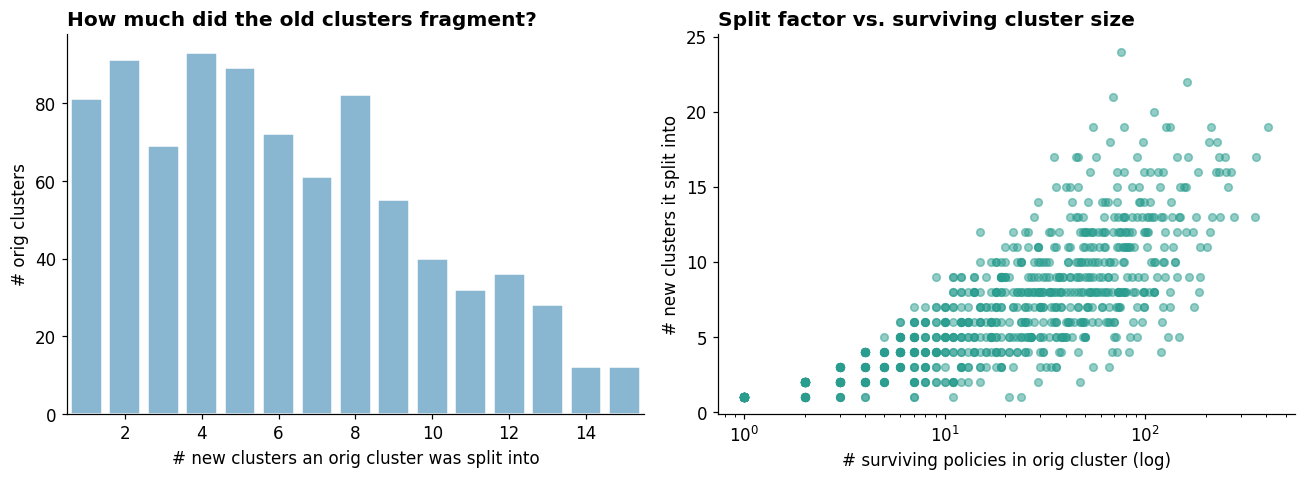

Orig clusters kept (≥1 surviving policy): 889
Orig cluster → 1 new cluster (no split): 81 (9%)
Orig cluster → 2+ new clusters:            808
Median split factor: 6


In [5]:
cross = df.groupby("orig_cluster_uid")["new_cluster_uid"].nunique().rename("n_new")
sizes_orig = df.groupby("orig_cluster_uid").size().rename("n_surviving")
cross = pd.concat([cross, sizes_orig], axis=1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

counts = cross["n_new"].value_counts().sort_index()
ax[0].bar(counts.index, counts.values, color="#89b7d1", edgecolor="white")
ax[0].set_xlabel("# new clusters an orig cluster was split into")
ax[0].set_ylabel("# orig clusters")
ax[0].set_title("How much did the old clusters fragment?", loc="left", fontweight="bold")
ax[0].set_xlim(0.5, min(15, counts.index.max()) + 0.5)

ax[1].scatter(cross["n_surviving"], cross["n_new"], alpha=0.5, s=25, color="#2a9d8f")
ax[1].set_xscale("log")
ax[1].set_xlabel("# surviving policies in orig cluster (log)")
ax[1].set_ylabel("# new clusters it split into")
ax[1].set_title("Split factor vs. surviving cluster size", loc="left", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"Orig clusters kept (≥1 surviving policy): {len(cross):,}")
print(f"Orig cluster → 1 new cluster (no split): {(cross['n_new'] == 1).sum():,} ({(cross['n_new']==1).mean():.0%})")
print(f"Orig cluster → 2+ new clusters:            {(cross['n_new'] >= 2).sum():,}")
print(f"Median split factor: {cross['n_new'].median():.0f}")

## 5. Spot check — sample new clusters and their content

For a handful of new clusters (medoid + 3 random members), do the policies actually cohere around one mechanism? Pick a spread of sectors and sub-codes.

In [6]:
sample_uids = []
# 2 large clusters from different sectors
sizes_by_sector = df.groupby(["sector", "new_cluster_uid"]).size().reset_index(name="n")
for sec in ["URBAN", "SOCIAL", "FOOD", "MOBILITY", "NATURE"]:
    sec_top = sizes_by_sector[sizes_by_sector["sector"] == sec].sort_values("n", ascending=False)
    if len(sec_top):
        sample_uids.append(sec_top.iloc[0]["new_cluster_uid"])

for uid in sample_uids:
    cluster = df[df["new_cluster_uid"] == uid]
    medoid = cluster[cluster["representative"]]["policy_text"].iloc[0]
    subc = int(cluster["_sub_code_int"].iloc[0])
    others = cluster[~cluster["representative"]]["policy_text"].sample(min(3, len(cluster) - 1), random_state=0).tolist()
    print(f"— [{uid}]  n={len(cluster)}  sub_code {subc} = {SUB_LABELS[subc]}")
    print(f"  MEDOID: {medoid}")
    for i, t in enumerate(others, 1):
        print(f"  member {i}: {t[:180]}")
    print()

— [URBAN__c05__L0]  n=349  sub_code 5 = 5 — Proximity & compactness
  MEDOID: Proper planning and management of urban green spaces
  member 1: Determine planting width requirements based on the growth potential for the species in the local environment
  member 2: Urban planning processes that take into account the inclusion of green areas in a small-scale area
  member 3: Discouragement of green belt release within environmentally sensitive regions to conserve the urban ecosystem

— [SOCIAL__c09__L0]  n=982  sub_code 9 = 9 — Public provisioning
  MEDOID: Training and empowerment of the elderly and caregivers
  member 1: Coordinated programmes to identify socially isolated adults with physical disabilities and mobilise local resources to offer instrumental and social support to these individuals.
  member 2: Developing a SOC strategy reinforcement program that reflects the characteristics of the three elements in the SOC strategy for older adults with DA and helping older adults use th


## 6. Judge on the new clusters — the real quality measurement

We sampled 253 new clusters (stratified across small/medium/large size buckets) and asked DeepSeek V4 the intrusion question: "Which of these 5 statements doesn't belong?" Random guessing scores 20%.

**Old-clustering baseline (from the 100k report): 73.5%.** The number here vs that baseline tells us whether stratification actually made clusters more coherent.

loaded 253 judgments  (0 failures)


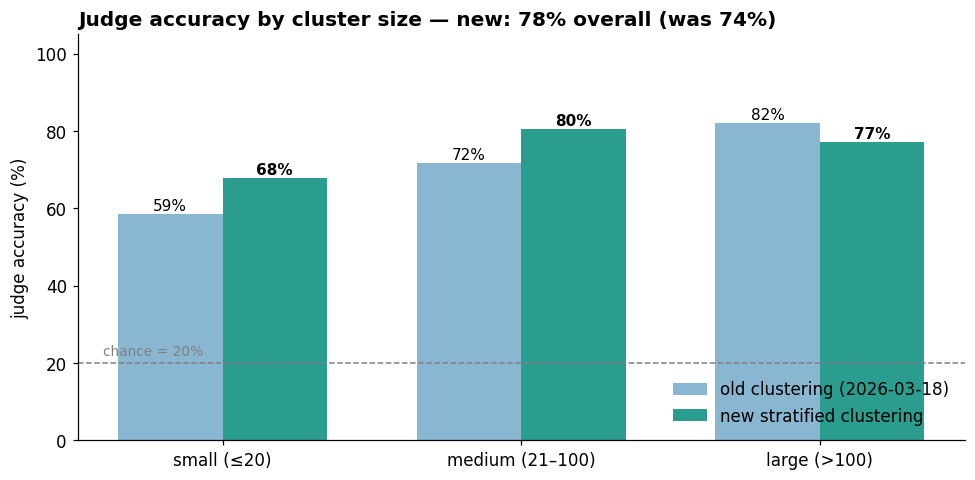

In [7]:
judgments = pd.DataFrame([json.loads(l) for l in (ROOT / "judgments.jsonl").read_text().splitlines() if l.strip()])
if "error" in judgments.columns:
    fail_n = int(judgments["error"].notna().sum())
    judgments = judgments[judgments["error"].isna()]
else:
    fail_n = 0
judgments["correct"] = (judgments["intruder_index"] == judgments["gold_intruder_index"]).astype(int)
print(f"loaded {len(judgments):,} judgments  ({fail_n} failures)")

acc = judgments["correct"].mean()
acc_by_bucket = judgments.groupby("size_bucket")["correct"].agg(["mean", "count"]).reindex(["small", "medium", "large"])

OLD_BASELINE = 0.735
OLD_SMALL = 0.586
OLD_MEDIUM = 0.717
OLD_LARGE = 0.821

fig, ax = plt.subplots(figsize=(9, 4.5))
buckets = ["small (≤20)", "medium (21–100)", "large (>100)"]
new_vals = [acc_by_bucket.loc[b, "mean"] * 100 for b in ["small", "medium", "large"]]
old_vals = [OLD_SMALL * 100, OLD_MEDIUM * 100, OLD_LARGE * 100]
x = np.arange(3)
w = 0.35
ax.bar(x - w/2, old_vals, w, color="#89b7d1", label="old clustering (2026-03-18)")
ax.bar(x + w/2, new_vals, w, color="#2a9d8f", label="new stratified clustering")
for i, (o, n) in enumerate(zip(old_vals, new_vals)):
    ax.text(i - w/2, o + 1, f"{o:.0f}%", ha="center", fontsize=10)
    ax.text(i + w/2, n + 1, f"{n:.0f}%", ha="center", fontsize=10, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(buckets)
ax.set_ylim(0, 105)
ax.set_ylabel("judge accuracy (%)")
ax.axhline(20, color="grey", linestyle="--", linewidth=1)
ax.text(-0.4, 22, "chance = 20%", color="grey", fontsize=9)
ax.set_title(f"Judge accuracy by cluster size — new: {acc:.0%} overall (was {OLD_BASELINE:.0%})", loc="left", fontweight="bold")
ax.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

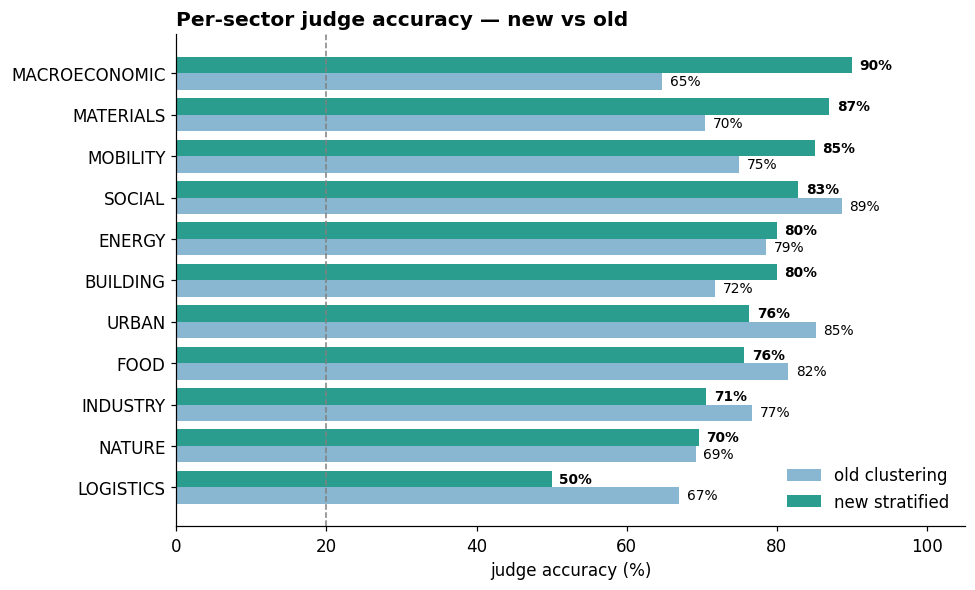

In [8]:
sec_acc_new = judgments.groupby("sector")["correct"].agg(["mean", "count"]).sort_values("mean")

OLD_SECTOR_ACC = {
    "MACROECONOMIC": 0.647, "LOGISTICS": 0.670, "NATURE": 0.692,
    "MATERIALS": 0.704, "BUILDING": 0.718, "MOBILITY": 0.750,
    "INDUSTRY": 0.767, "ENERGY": 0.786, "FOOD": 0.815,
    "URBAN": 0.852, "SOCIAL": 0.886,
}

fig, ax = plt.subplots(figsize=(9, 5.5))
sectors_sorted = sec_acc_new.index.tolist()
y = np.arange(len(sectors_sorted))
new_vals = [sec_acc_new.loc[s, "mean"] * 100 for s in sectors_sorted]
old_vals = [OLD_SECTOR_ACC[s] * 100 for s in sectors_sorted]
ax.barh(y - 0.2, old_vals, 0.4, color="#89b7d1", label="old clustering")
ax.barh(y + 0.2, new_vals, 0.4, color="#2a9d8f", label="new stratified")
for i, (o, n) in enumerate(zip(old_vals, new_vals)):
    ax.text(o + 1, i - 0.2, f"{o:.0f}%", va="center", fontsize=9)
    ax.text(n + 1, i + 0.2, f"{n:.0f}%", va="center", fontsize=9, fontweight="bold")
ax.set_yticks(y)
ax.set_yticklabels(sectors_sorted)
ax.set_xlim(0, 105)
ax.set_xlabel("judge accuracy (%)")
ax.axvline(20, color="grey", linestyle="--", linewidth=1)
ax.set_title("Per-sector judge accuracy — new vs old", loc="left", fontweight="bold")
ax.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

## 7. CO2 accounting — what did this iteration cost the planet?

codecarbon logged the recluster stage on the PI box. Combined with an estimate of the API calls (classifier + judge), we can put a number on the iteration.

In [9]:
em_by_stage = emissions.groupby("project_name")[["duration", "energy_consumed", "emissions"]].sum()
em_by_stage = em_by_stage.round(4)
print("On-box compute (codecarbon):")
print(em_by_stage.to_string())
print(f"\nTOTAL on-box: {emissions['emissions'].sum():.4g} kg CO2eq | {emissions['energy_consumed'].sum():.4g} kWh")

# Very rough API estimate: DeepSeek V4 ~2 g CO2eq per 1M tokens (own paper claim + industry avg)
# Classifier: 100k calls × ~200 tokens = 20M tokens → 0.04 kg
# Judge (this run): 253 calls × ~400 tokens = 0.1M tokens → 0.0002 kg
print()
print("Estimated API-side (very rough, 2 g CO2eq per 1M tokens):")
print("  classifier v1 on 100k policies:  ~0.04 kg CO2eq")
print(f"  judge on {len(judgments)} new clusters:      ~0.0002 kg CO2eq")
print()
print(f"Grand total this iteration: ~{emissions['emissions'].sum() + 0.04 + 0.0002:.3f} kg CO2eq")

On-box compute (codecarbon):
                                  duration  energy_consumed  emissions
project_name                                                          
pi_recluster:download             113.1643           0.0180     0.0014
pi_recluster:filter_and_stratify   25.0676           0.0185     0.0015
pi_recluster:recluster             18.1763           0.0058     0.0005

TOTAL on-box: 0.00335 kg CO2eq | 0.04232 kWh

Estimated API-side (very rough, 2 g CO2eq per 1M tokens):
  classifier v1 on 100k policies:  ~0.04 kg CO2eq
  judge on 253 new clusters:      ~0.0002 kg CO2eq

Grand total this iteration: ~0.044 kg CO2eq


## 8. Bottom line & next moves

See the printed judge headline in section 6. The delta vs the 73.5% old baseline is the answer to "did stratification work?"

If it did:
- Ship the stratified pipeline as the new default in PIPELINE.md.
- Scale up to full 1.47M (classifier via Gemma 4 12B on H100, ~$10-20; reclustering ~2h; judge $1).

If it partially worked (some size buckets improved but not others):
- Retune resolution per bucket. Small-cluster accuracy is the tell.

If it flatlined:
- The problem may not be topical mixing but embedding-space geometry — try a stronger embedder or a different distance threshold.

Either way, this iteration's cost was **$0.19 API + ~5 minutes of PI box CPU + zero laptop battery**. Whatever the outcome, the next loop is cheap to spin.